# Insurance Cost Prediction

## Project Overview

This project develops an end-to-end machine learning pipeline for predicting
individual medical insurance charges.

The project focuses on building a reproducible and deployment-oriented
regression workflow rather than only maximizing predictive performance.

### Objectives

- Understand the insurance dataset and identify important patterns.
- Build domain-informed features.
- Create a leakage-safe preprocessing pipeline.
- Compare multiple regression algorithms.
- Use cross-validation for robust model evaluation.
- Tune promising models using randomized hyperparameter search.
- Select and retrain the final model using the combined training and validation data.
- Evaluate the final model once on an untouched test set.
- Analyze model errors and feature importance.
- Track experiments using MLflow.
- Export the final pipeline for deployment.

### Target

`charges`

### Main Features

- `age`
- `sex`
- `bmi`
- `children`
- `smoker`
- `region`

### Evaluation Metrics

- RMSE
- MAE
- R²

# 🛠️ Production Environment Setup
 ## 🛠️ Core Python Incantations
- **NumPy**: Summon the elemental forces of arrays and numerical computation.  
- **Pandas**: Your grimoire for taming tabular data.  
- **Matplotlib & Seaborn**: Paint your data stories with the colors of insight.  
- **SciPy**: Harness statistics to uncover hidden patterns.  
- **Joblib**: Safely store your magical artifacts (models and transformers).  
- **JSON**: Speak the language of configuration spirits.  
- **datetime, os, time**: Track time, navigate your data realm, and record every step of your journey.

## 🧰 Scikit-Learn Spells
- **Datasets & Preprocessing**: Fetch real-world datasets, scale and transform features, and generate polynomial enchantments for non-linear mysteries.  
- **Model Selection & Validation**: Split, cross-validate, and search for the perfect hyperparameters to summon the strongest models.  
- **Feature Alchemy**: Select and refine features with SelectKBest, RFE, and other mystical techniques.  
- **Regression Wizards**: From humble Linear Regression to powerful ensembles like Random Forests and Gradient Boosting, your models will bend reality.  
- **Support Vector Magic**: Tame complex patterns with SVR.  
- **Evaluation Charms**: Measure the fate of your predictions with RMSE, MAE, and R².  
- **Interpretability Orbs**: Understand the true power of your features using permutation importance and partial dependence plots.

In [1]:
# 🛠️ Advanced imports for production ML

# Suppress warnings for cleaner outputs
import warnings
warnings.filterwarnings('ignore')

# 🔧 Core Python libraries
import numpy as np           # Efficient numerical computations
import pandas as pd          # Data manipulation and analysis
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns        # Advanced visualization
from scipy import stats      # Statistical functions
import joblib               # Save/load large models and preprocessing objects
import json                 # Handle JSON configs and outputs
from datetime import datetime  # Timestamping for logs
import os                   # File system operations
import time                 # Time tracking for experiments

# 🧰 Sklearn libraries - expanded for advanced ML workflows
from sklearn.model_selection import (
    train_test_split,     # Split data into train/test sets
    cross_val_score,      # Cross-validation scoring
    GridSearchCV,         # Hyperparameter tuning (grid search)
    RandomizedSearchCV    # Hyperparameter tuning (randomized search)
)
from sklearn.preprocessing import (
    StandardScaler,       # Feature scaling (zero-mean, unit variance)
    RobustScaler,         # Scaling robust to outliers
    PolynomialFeatures    # Generate polynomial features for non-linear relationships
)
from sklearn.pipeline import Pipeline, FeatureUnion  # Build modular pipelines
from sklearn.compose import ColumnTransformer         # Apply different preprocessing to columns
from sklearn.feature_selection import (
    SelectKBest,          # Univariate feature selection
    f_regression,         # Scoring function for regression
    RFE                   # Recursive feature elimination
)
from sklearn.linear_model import (
    LinearRegression,     # Baseline regression
    Ridge,                # L2-regularized regression
    Lasso,                # L1-regularized regression
    ElasticNet            # Combination of L1 and L2 regularization
)
from sklearn.ensemble import (
    RandomForestRegressor,       # Ensemble of decision trees
    GradientBoostingRegressor,   # Boosted trees for regression
    VotingRegressor              # Combine multiple regressors
)
from sklearn.svm import SVR               # Support Vector Regression
from sklearn.metrics import (
    mean_squared_error,  # Regression metric
    r2_score,            # Regression metric
    mean_absolute_error  # Regression metric
)
from sklearn.inspection import (
    permutation_importance,       # Feature importance
    PartialDependenceDisplay      # Partial dependence plots
)
from sklearn.base import BaseEstimator, TransformerMixin
# utility that makes a new, unfitted copy of an estimator or pipeline while keeping its settings.
from sklearn.base import clone

# 🧪 Advanced model tracking with MLflow
import mlflow                  # Experiment tracking
import mlflow.sklearn          # Log sklearn models
from mlflow.models.signature import infer_signature  # Auto-capture input/output schema for reproducible deployment


# 🎛️ Configuration & Reproducibility

Before we start modeling, it’s crucial to **establish reproducible and scalable experiment settings**. This ensures that results are consistent, experiments are traceable, and your workflow is production-ready.

### Key Components:

1. **Reproducibility**
   - `RANDOM_STATE = 42`: Ensures that every run produces the same train/test splits, random sampling, and model results.
   - `TEST_SIZE = 0.2`: Reserves 20% of the data for final evaluation.
   - `VAL_SIZE = 0.2`: Reserves a portion of the training data for validation and hyperparameter tuning.
   - `CV_FOLDS = 5`: Use 5-fold cross-validation to evaluate models robustly.
   - `N_JOBS = -1`: Utilizes all available CPU cores to speed up computations.

2. **Organized Project Structure**
   - `MODEL_DIR = "models"`: All trained models are stored in a dedicated folder.
   - `EXPERIMENT_DIR = "experiments"`: All MLflow experiment logs, metrics, and artifacts are saved in a centralized location.
   - `os.makedirs(..., exist_ok=True)`: Ensures directories exist, preventing file errors during training or logging.

3. **MLflow Experiment Tracking**
   - `mlflow.set_tracking_uri(...)` points MLflow to the experiment folder.
   - `mlflow.set_experiment(experiment_name)` creates a named experiment for this project.
   - This allows you to **log models, metrics, and hyperparameters**, enabling easy comparison across experiments.

> 💡 **Pro Tip:** Proper configuration and tracking is like laying the foundation of a building—everything built on top will be reliable, reproducible, and easy to maintain.


In [2]:
class Config:
    # Reproducibility - Critical for production!
    RANDOM_STATE = 42
    TEST_SIZE = 0.2
    VAL_SIZE = 0.2  # NEW: Validation set for tuning
    CV_FOLDS = 5
    N_JOBS = -1  # Use all available cores
    
    # Model directories - Organized project structure
    MODEL_DIR = "models"
    EXPERIMENT_DIR = "experiments"
    
    # Create directories if they don't exist
    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(EXPERIMENT_DIR, exist_ok=True)
    
config = Config()

# Allow the local file-based MLflow backend
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

# Initialize MLflow for experiment tracking
mlflow.set_tracking_uri(f"file://{os.path.abspath(config.EXPERIMENT_DIR)}")
experiment_name = "insurance_regression"
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='file:///Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing/experiments/972338051452133885', creation_time=1791369792724, effective_trace_archival_retention=None, experiment_id='972338051452133885', last_update_time=1791369792724, lifecycle_stage='active', name='insurance_regression', tags={}, trace_location=None, workspace='default'>

## Step 1: Data Loading & Understanding

We will use this dataset to explore and later predict insurance charges.

In this section, we load the data and inspect its size, columns, data types,
sample rows, summary statistics, missing values, duplicate rows, and categories.
We will make data-cleaning decisions in the preprocessing section.

In [3]:
df = pd.read_csv("Dataset/insurance.csv")
print(f"Rows shape: {df.shape[0]:,}")
print(f"Columns shape: {df.shape[1]}")
df.head(5)


Rows shape: 1,338
Columns shape: 7


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 🔍 Step 2: Exploratory Data Analysis (EDA)

Before building models, we must **understand our data**:
- Check for missing values
- Understand distributions
- Detect outliers
- Explore relationships between features

In [4]:
# Basic statistics
print("=" * 70)
print("📊 DATASET STATISTICS")
print("=" * 70)
print(df.describe())

📊 DATASET STATISTICS
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


#### checking missing value

In [6]:
print("Missing value:\n", df.isnull().sum())
print("Duplicated value:", df.duplicated().sum())

Missing value:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Duplicated value: 1


In [7]:
# remove the duplicated
df_clean = df.drop_duplicates().reset_index(drop=True)
print("New Dataframe", df_clean.duplicated().sum())

New Dataframe 0


In [8]:
categorical_columns = df_clean.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df_clean[column].value_counts(dropna=False))


sex
sex
male      675
female    662
Name: count, dtype: int64

smoker
smoker
no     1063
yes     274
Name: count, dtype: int64

region
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


### Visualizations
will visualize the feature distributions and their relationships with insurance
charges. These plots help us identify skew, unusual values, and patterns that may
matter when choosing preprocessing steps and regression models.

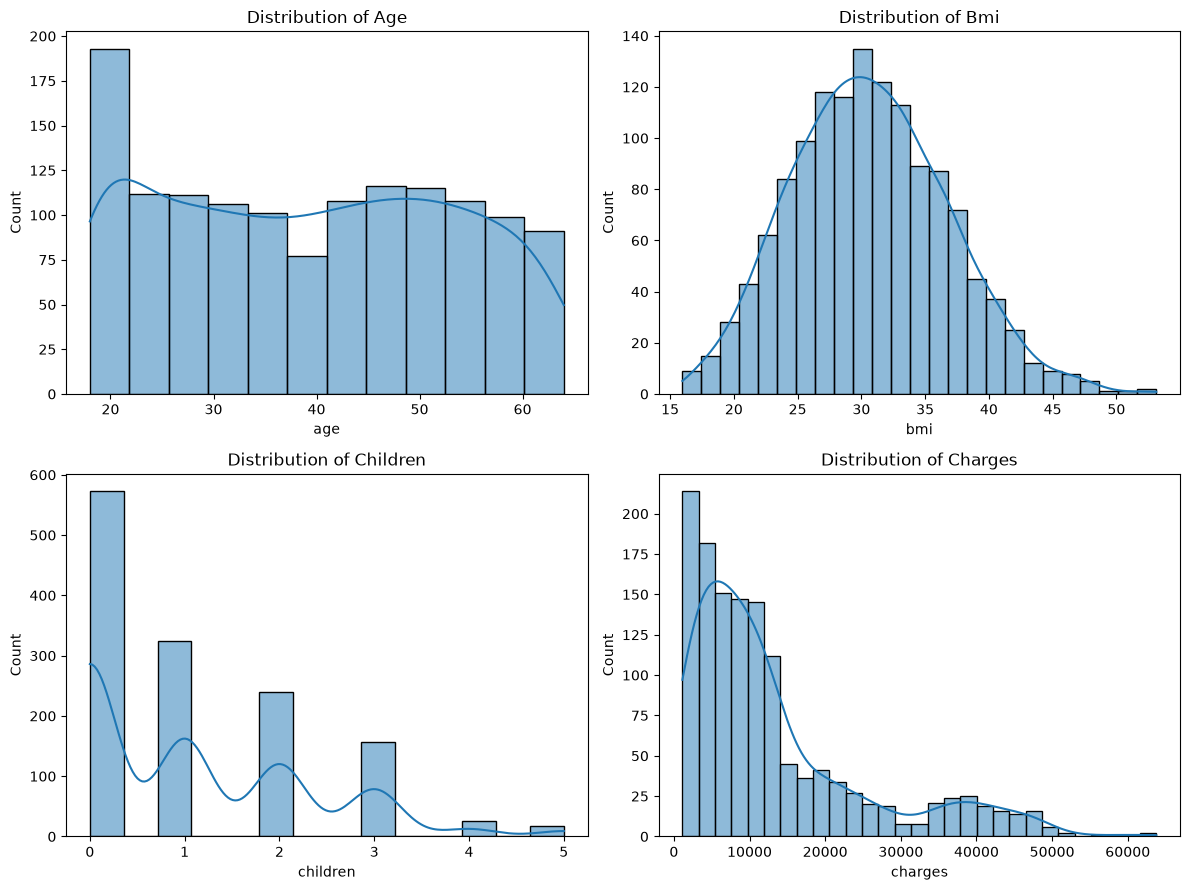

In [9]:
numeric_columns = ["age", "bmi", "children", "charges"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for column, ax in zip(numeric_columns, axes.flat):
    sns.histplot(data=df_clean, x=column, kde=True, ax=ax)
    ax.set_title(f"Distribution of {column.title()}")

plt.tight_layout()
plt.show()

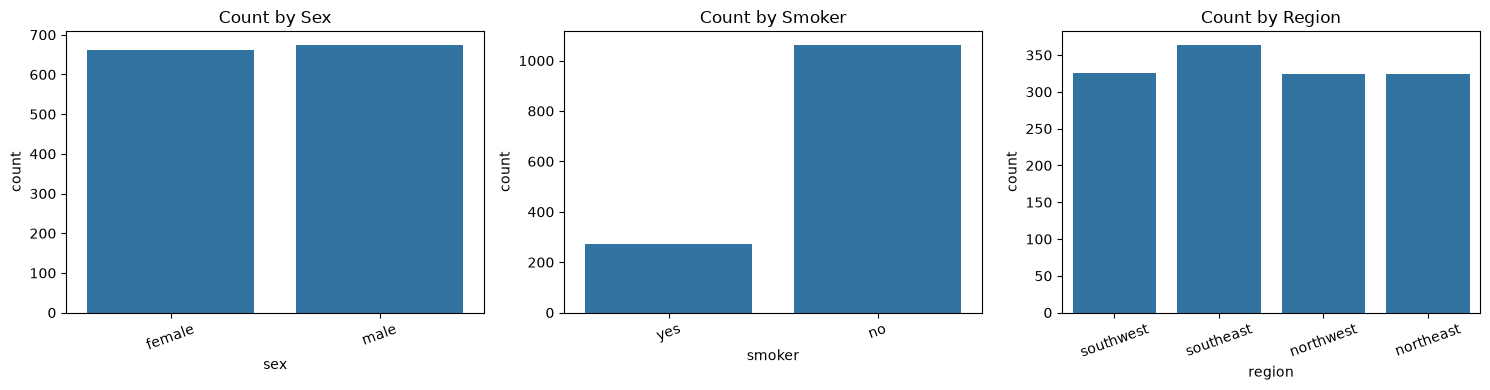

In [10]:
categorical_columns = ["sex", "smoker", "region"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for column, ax in zip(categorical_columns, axes):
    sns.countplot(data=df_clean, x=column, ax=ax)
    ax.set_title(f"Count by {column.title()}")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

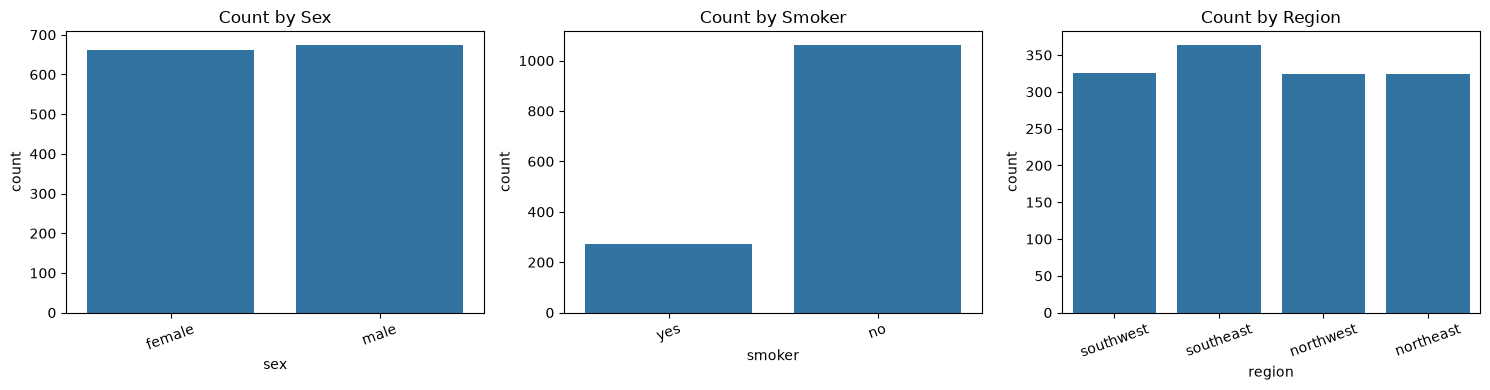

In [11]:
categorical_columns = ["sex", "smoker", "region"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for column, ax in zip(categorical_columns, axes):
    sns.countplot(data=df_clean, x=column, ax=ax)
    ax.set_title(f"Count by {column.title()}")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

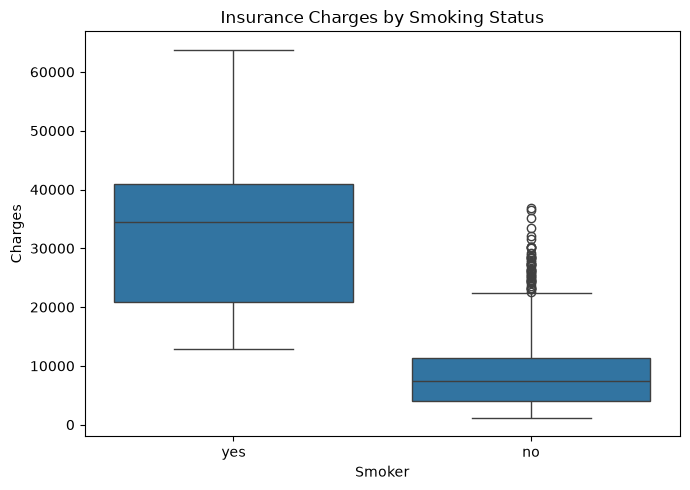

In [12]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df_clean, x="smoker", y="charges")

plt.title("Insurance Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.tight_layout()
plt.show()

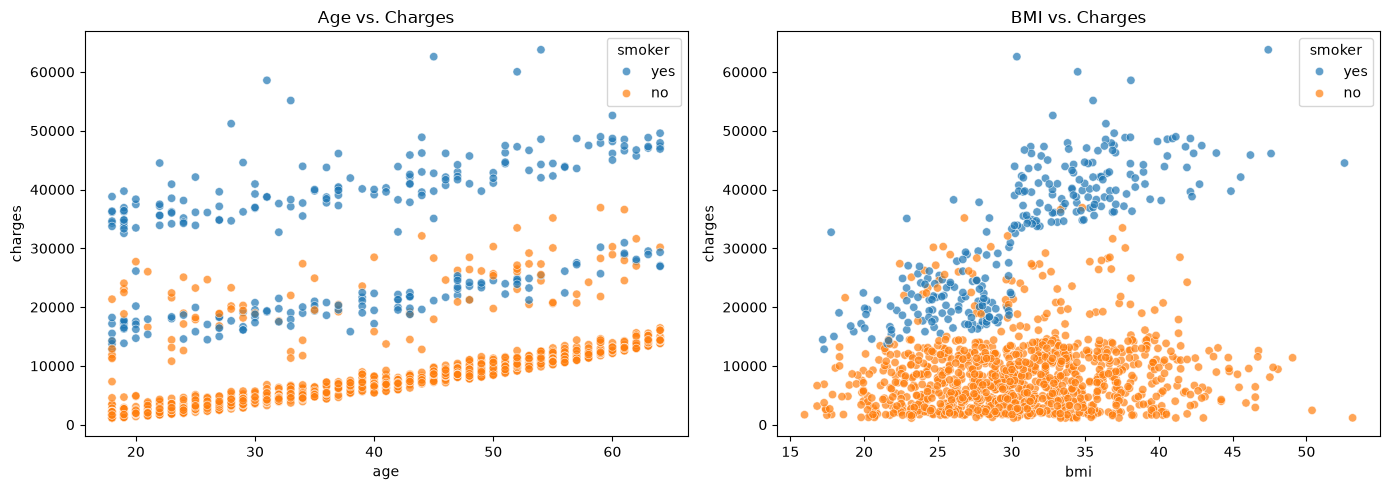

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_clean,
    x="age",
    y="charges",
    hue="smoker",
    alpha=0.7,
    ax=axes[0],
)
axes[0].set_title("Age vs. Charges")

sns.scatterplot(
    data=df_clean,
    x="bmi",
    y="charges",
    hue="smoker",
    alpha=0.7,
    ax=axes[1],
)
axes[1].set_title("BMI vs. Charges")

plt.tight_layout()
plt.show()

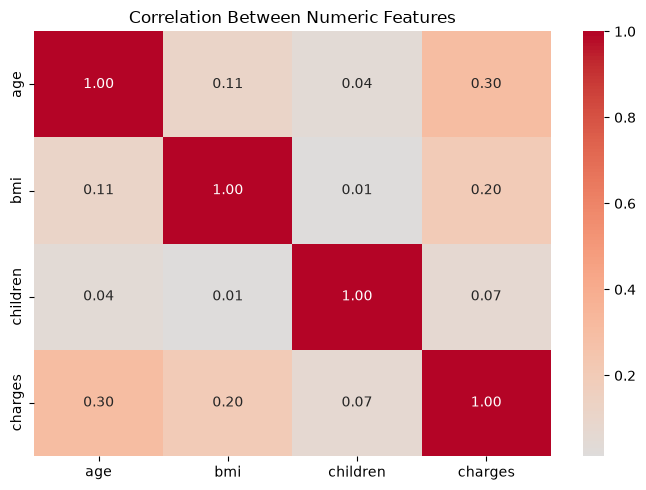

In [14]:
correlation_matrix = df_clean[numeric_columns].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
)

plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

## step 3: Data Preprocessing: Separate Features and Target

The target variable is `charges`. We keep it separate from the input features
so it cannot accidentally be used as an input to predict itself.

We split the data before fitting preprocessing. The encoder will learn categories
from the training features, then apply that same encoding to the test features.

In [15]:
# Keep the target separate from the input features
X = df_clean.drop(columns="charges")
y = df_clean["charges"]

# Hold out the test set first
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_STATE,
)

# Split the remaining data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=config.VAL_SIZE,
    random_state=config.RANDOM_STATE,
)

print(f"Training rows:   {len(X_train):,}")
print(f"Validation rows: {len(X_val):,}")
print(f"Test rows:       {len(X_test):,}")
print(f"Input features:  {X_train.shape[1]}")

Training rows:   855
Validation rows: 214
Test rows:       268
Input features:  6


In [16]:
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = X_train.select_dtypes(
    include="number"
).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['sex', 'smoker', 'region']
Numeric columns: ['age', 'bmi', 'children']


###  Encoding categorical variables using OneHotEncoder

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_cols,
        ),
    ],
    remainder="drop",
)

X_train_prepared = preprocessor.fit_transform(X_train)
X_val_prepared = preprocessor.transform(X_val)
X_test_prepared = preprocessor.transform(X_test)

print("Prepared feature shapes:")
print("Training:  ", X_train_prepared.shape)
print("Validation:", X_val_prepared.shape)
print("Test:      ", X_test_prepared.shape)

Prepared feature shapes:
Training:   (855, 8)
Validation: (214, 8)
Test:       (268, 8)


In [18]:
print("Dataframe shape:", df_clean.shape)
print("Exact duplicates:", df_clean.duplicated().sum())
print("TEST_SIZE:", config.TEST_SIZE)
print("VAL_SIZE:", config.VAL_SIZE)

Dataframe shape: (1337, 7)
Exact duplicates: 0
TEST_SIZE: 0.2
VAL_SIZE: 0.2


# 🧠  Feature Engineering and 🏗️ Building the Final Preprocessing Pipeline
## 🚀`AdvancedFeatureEngineer` Class


💡 **Pro Tip:** Turning feature engineering into a reusable transformer is a **best practice in production ML** — it allows you to deploy exactly the same transformation logic during training and inference, ensuring consistency.




In [41]:
class InsuranceFeatureEngineer(BaseEstimator, TransformerMixin):
    """Add insurance-specific features. Same name, same fit/transform API
    as the previous version, so the rest of the pipeline keeps working."""
 
    REQUIRED_COLUMNS = {"age", "bmi", "children", "smoker"}
 
    def fit(self, X, y=None):
        missing_columns = self.REQUIRED_COLUMNS - set(X.columns)
 
        if missing_columns:
            raise ValueError(
                f"Missing required columns: {sorted(missing_columns)}"
            )
 
        self.feature_names_in_ = list(X.columns)
        return self
 
    def transform(self, X):
        X_engineered = X.copy()
 
        # Kept from the previous version
        X_engineered["age_squared"] = X_engineered["age"] ** 2
 
        # Basic flags
        is_smoker = (X_engineered["smoker"] == "yes").astype(int)
        X_engineered["is_obese"] = (X_engineered["bmi"] >= 30).astype(int)
        X_engineered["has_children"] = (X_engineered["children"] > 0).astype(int)
 
        # Interactions: smoking amplifies the cost effect of BMI and age
        X_engineered["smoker_obese"] = is_smoker * X_engineered["is_obese"]
        X_engineered["smoker_bmi"] = is_smoker * X_engineered["bmi"]
        X_engineered["smoker_age"] = is_smoker * X_engineered["age"]
 
        return X_engineered
 

## 🧭 Outlier Handling with IQR — Making the Data More Robust

In the **previous notebook**, our preprocessing pipeline we made StandardScaler()

This was a **good starting point**, but it only applied  — meaning it didn’t actually address **outliers**, which can **skew scaling and hurt model performance**.

---

## 🚀 Why Upgrade to IQR-Based Outlier Handling

Outliers can **distort model training**, especially for algorithms sensitive to input scale (e.g., Linear Regression, Ridge, Lasso, SVM).
To fix this, we introduce a **dedicated outlier handling stage** *before* scaling.

### 🧮 IQR Outlier Detection Logic

For each feature:

1. Calculate **Q1 (25th percentile)** and **Q3 (75th percentile)**.
2. Compute **IQR = Q3 − Q1**.
3. Define:
   $$
   \text{Lower Bound} = Q1 - 1.5 \times IQR
   \quad
   \text{Upper Bound} = Q3 + 1.5 \times IQR
   $$
4. Clip any values outside this range to make the distribution **more stable**.

✅ **Why this matters:**

* Stabilizes scaling
* Reduces the influence of extreme values
* Keeps the data intact (no row deletion)
* Makes the pipeline more production-ready



In [20]:
class OutlierHandler(BaseEstimator, TransformerMixin):
    """Clip selected DataFrame columns using IQR bounds learned during fit."""

    def __init__(self, columns, factor=1.5):
        self.columns = columns
        self.factor = factor

    def fit(self, X, y=None):
        missing_columns = set(self.columns) - set(X.columns)

        if missing_columns:
            raise ValueError(
                f"Columns not found: {sorted(missing_columns)}"
            )

        self.bounds_ = {}

        for column in self.columns:
            q1 = X[column].quantile(0.25)
            q3 = X[column].quantile(0.75)
            iqr = q3 - q1

            self.bounds_[column] = (
                q1 - self.factor * iqr,
                q3 + self.factor * iqr,
            )

        return self

    def transform(self, X):
        X_clipped = X.copy()

        for column, (lower_bound, upper_bound) in self.bounds_.items():
            X_clipped[column] = X_clipped[column].clip(
                lower=lower_bound,
                upper=upper_bound,
            )

        return X_clipped

## 🏗️ Building the Final Preprocessing Pipeline

We’ve now developed and tested each **individual component** of our preprocessing workflow:

1. 🧠 **`InsuranceFeatureEngineer`** creates domain-informed nonlinear features and interactions, including age², obesity status, smoking interactions with BMI and age, and smoking–obesity interaction.
2. 🧹 **`OutlierHandler`** → detects and **clips extreme values** using the IQR method for robust statistics.
3. 📏 **`RobustScaler`** → scales features in a way that’s **less sensitive to outliers** compared to `StandardScaler`.

> 🆚 *In the previous notebook, we only used a simple scaler (and optional polynomial expansion).
> Now, we’re assembling a **production-ready** ML system with layered transformations.*

---

## 🚀 Why a Unified Pipeline Matters

✅ Ensures **clean, reproducible transformations**
✅ Keeps preprocessing **modular and maintainable**
✅ Integrates seamlessly with model training & cross-validation
✅ Allows us to **deploy the same pipeline** in production (no data leakage)

---

## 🧪 Let’s Build It

We’ll combine all steps into a single `Pipeline` object:


In [42]:
numeric_columns = [
    "age", "bmi", "children",
    "age_squared", "smoker_bmi", "smoker_age",
]
binary_columns = ["is_obese", "has_children", "smoker_obese"]
categorical_columns = ["sex", "smoker", "region"]

column_preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numeric_columns),
        ("bin", "passthrough", binary_columns),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_columns,
        ),
    ],
    remainder="drop",
)

# Same step names and order as before:
# feature_engineer -> outlier_handler -> preprocessor
preprocessing_pipeline = Pipeline(
    steps=[
        ("feature_engineer", InsuranceFeatureEngineer()),
        ("outlier_handler", OutlierHandler(columns=["bmi"], factor=1.5)),
        ("preprocessor", column_preprocessor),
    ]
)

In [22]:
X_train_processed = preprocessing_pipeline.fit_transform(X_train, y_train)
X_val_processed = preprocessing_pipeline.transform(X_val)
X_test_processed = preprocessing_pipeline.transform(X_test)

print("Processed feature shapes:")
print("Training:  ", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:      ", X_test_processed.shape)

print("\nProcessed feature names:")
print(
    preprocessing_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print("\nBMI bounds learned from training data:")
print(
    preprocessing_pipeline
    .named_steps["outlier_handler"]
    .bounds_["bmi"]
)

Processed feature shapes:
Training:   (855, 9)
Validation: (214, 9)
Test:       (268, 9)

Processed feature names:
['num__age' 'num__bmi' 'num__children' 'num__age_squared' 'cat__sex_male'
 'cat__smoker_yes' 'cat__region_northwest' 'cat__region_southeast'
 'cat__region_southwest']

BMI bounds learned from training data:
(np.float64(13.394999999999992), np.float64(47.59500000000001))


## 🧠 Expanding Our Model Arsenal: From Basics to Advanced

In the **previous notebook**, we kept our model set simple — focusing on:

```python
# OLD: Simple baseline models
'Model': ['Linear Regression', 'Ridge (best)', 'Lasso (best)', 'Polynomial (deg=2)']
```

This was great for:

* ✅ Establishing **baseline performance**
* ✅ Understanding core concepts like regularization (`Ridge`, `Lasso`)
* ✅ Demonstrating feature transformation with polynomial terms

But real-world problems often demand **stronger models** that can capture **nonlinearities**, **complex interactions**, and **robust generalization**.

---

## 🆕 Introducing Advanced Models

We now upgrade our model set to include a **diverse mix of linear, regularized, tree-based, and ensemble learners**:

| Model Name                     | Type                  | Why We Add It 🧭                                                    |
| ------------------------------ | --------------------- | ------------------------------------------------------------------- |
| `LinearRegression`             | Linear Baseline       | A clean baseline — interpretable and fast.                          |
| `Ridge Regression`             | Regularized Linear    | Controls overfitting with L2 regularization.                        |
| `Lasso Regression`             | Regularized Linear    | Performs **feature selection** via L1 penalty.                      |
| `ElasticNet` 🆕                | Hybrid Regularization | Combines L1 + L2 — more flexible for correlated features.           |
| `RandomForestRegressor` 🆕     | Tree Ensemble         | Handles nonlinearities & interactions without feature engineering.  |
| `GradientBoostingRegressor` 🆕 | Boosting Ensemble     | Learns sequentially, improving weak learners over time.             |
| `Support Vector Regression` 🆕 | Kernel Method         | Captures complex relationships using kernel tricks.                 |
| `VotingRegressor` 🆕           | Ensemble Strategy     | Combines multiple models for **stronger, more stable performance**. |

---

## ⚡ Why This Matters in Production

✅ **Model diversity** improves your chances of finding a high-performing model.
✅ **Regularized models** give stability and interpretability.
✅ **Ensemble methods** usually outperform single models in complex tasks.
✅ **Nonlinear models** can capture patterns linear models miss.

This setup also makes it easy to:

* 📊 Compare models consistently
* 🧪 Run hyperparameter tuning later
* 🧠 Blend models into a **final ensemble**

---

## 🧱 Implementation



In [43]:
# define advanced models - Expanded from previous work
advanced_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=config.RANDOM_STATE),
    'Lasso Regression': Lasso(random_state=config.RANDOM_STATE),
    'ElasticNet': ElasticNet(random_state=config.RANDOM_STATE),  # NEW: Combines L1 + L2
    'Random Forest': RandomForestRegressor(random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS),
    'Gradient Boosting': GradientBoostingRegressor(random_state=config.RANDOM_STATE),  # NEW: Sequential learning
    'Support Vector Regression': SVR(),  # NEW: Different approach
}

# NEW: Voting Ensemble - Combines multiple models
voting_ensemble = VotingRegressor([
    ('ridge', Ridge(random_state=config.RANDOM_STATE)),
    ('rf', RandomForestRegressor(random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS)),
    ('gb', GradientBoostingRegressor(random_state=config.RANDOM_STATE))
])

advanced_models['Voting Ensemble'] = voting_ensemble

print(f"\n🎯 MODEL PORTFOLIO ({len(advanced_models)} models):")


🎯 MODEL PORTFOLIO (8 models):



## 🧹Step-by-Step lets build the model training and logging with mlflow 
# Helper 1: Basic Training & Evaluation
This helper focuses only on:

training the model,

predicting on both train and validation sets, and

calculating key metrics (RMSE, R², MAE, training time, overfitting gap).


In [44]:
def build_model_pipeline(model):
    """Combine insurance preprocessing with a regression model."""
    return Pipeline(
        steps=[
            ("preprocessing", clone(preprocessing_pipeline)),
            ("regressor", clone(model)),
        ]
    )

In [45]:
def train_and_evaluate(model_pipeline, X_train, y_train, X_val, y_val):
    """Fit on training data and evaluate on train and validation data."""
    start_time = time.time()
    model_pipeline.fit(X_train, y_train)
    training_time = time.time() - start_time

    y_train_pred = model_pipeline.predict(X_train)
    y_val_pred = model_pipeline.predict(X_val)

    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)

    metrics = {
        "train_rmse": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "val_rmse": np.sqrt(mean_squared_error(y_val, y_val_pred)),
        "train_r2": train_r2,
        "val_r2": val_r2,
        "train_mae": mean_absolute_error(y_train, y_train_pred),
        "val_mae": mean_absolute_error(y_val, y_val_pred),
        "training_time": training_time,
        "overfitting_gap": train_r2 - val_r2,
    }

    return metrics, model_pipeline

# Helper 2: Cross-Validation

It evaluates how well a model generalizes to **unseen data** using **cross-validation** — instead of just relying on a single train–validation split.

---

### ⚡ Step-by-step breakdown:

1. **`cross_val_score`** from `sklearn.model_selection`
   This function automatically:

   * Splits your training set into multiple folds (e.g., 5 parts).
   * Trains the model on `k-1` folds (e.g., 4 folds).
   * Tests the model on the remaining fold.
   * Repeats this process `k` times (rotating the test fold each time).

   👉 This is called **k-fold cross-validation**.


In [46]:
def compute_cross_validation(model, X_train, y_train):
    """Cross-validate the full preprocessing-and-model pipeline."""
    model_pipeline = build_model_pipeline(model)

    cv_scores = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv=config.CV_FOLDS,
        scoring="r2",
        n_jobs=config.N_JOBS,
    )

    return cv_scores.mean(), cv_scores.std()

### 📦 Helper 3 — MLflow Logging

This helper function simplifies **experiment tracking with MLflow** by:

1. **Logging model hyperparameters** → so you know exactly how the model was configured.
2. **Logging evaluation metrics** → includes training/validation scores and cross-validation results.
3. **Saving the model artifact** → allows you to **reproduce or deploy** the exact trained model later.

> Using this function ensures that each experiment is **cleanly tracked, reproducible, and easy to compare** without cluttering your main training code.


In [47]:
def log_to_mlflow(model_pipeline, metrics, cv_mean, cv_std, run_name):
    """Log parameters, metrics, and the trained pipeline to MLflow."""
    with mlflow.start_run(run_name=run_name):
        regressor = model_pipeline.named_steps["regressor"]

        # Log the model name and simple hyperparameters.
        mlflow.log_param("regressor_class", type(regressor).__name__)

        simple_params = {
            name: value
            for name, value in regressor.get_params(deep=False).items()
            if isinstance(value, (str, int, float, bool))
        }
        mlflow.log_params(simple_params)

        # Log evaluation metrics.
        metrics_to_log = {
            name: float(value)
            for name, value in metrics.items()
            if name != "training_time"
        }
        metrics_to_log["cv_r2_mean"] = float(cv_mean)
        metrics_to_log["cv_r2_std"] = float(cv_std)
        mlflow.log_metrics(metrics_to_log)

        # Log the full preprocessing-and-model pipeline.
        mlflow.sklearn.log_model(
            model_pipeline,
            "model",
            serialization_format="cloudpickle",
        )

### 🚀 Advanced Model Evaluation

This function combines the full evaluation workflow into a **clean, easy-to-follow step**:

1. **Train & Evaluate** → fits the model and computes metrics on both training and validation sets.
2. **Cross-Validation** → estimates robust performance and stability using k-fold splits.
3. **MLflow Logging** → tracks hyperparameters, metrics, and saves the model artifact for reproducibility.

> ✅ With this structure, you get **all key insights and tracking** without cluttering your main training loop.


In [48]:
def evaluate_model_advanced(
    model, X_train, X_val, y_train, y_val, model_name,
):
    """Train, evaluate, cross-validate, and log one model."""
    model_pipeline = build_model_pipeline(model)

    metrics, trained_pipeline = train_and_evaluate(
        model_pipeline, X_train, y_train, X_val, y_val,
    )

    cv_mean, cv_std = compute_cross_validation(
        model, X_train, y_train,
    )

    metrics["cv_r2_mean"] = cv_mean
    metrics["cv_r2_std"] = cv_std

    log_to_mlflow( 
        trained_pipeline, metrics, cv_mean, cv_std, model_name,
    )

    return metrics, trained_pipeline

### 🎯 Run & Track All Advanced Models

This loop automates the **training, evaluation, and logging** of all selected models:

1. Iterates through each model in `advanced_models`.
2. Uses the simplified `evaluate_model_advanced` function to:

   * Train the model
   * Evaluate on training & validation sets
   * Run cross-validation
   * Log everything to MLflow
3. Records metrics and trained models in dictionaries for easy reference.
4. Displays **validation R²**, **cross-validation mean ± std**, and flags potential overfitting.

> ✅ This setup ensures **consistent evaluation, reproducibility, and clean experiment tracking** without manual repetition for each model.


In [49]:
print("Starting advanced model evaluation...")

results = {}
trained_models = {}

for name, model in advanced_models.items():
    print(f"\nTraining {name}...")

    metrics, trained_pipeline = evaluate_model_advanced(
        model,
        X_train,
        X_val,
        y_train,
        y_val,
        name,
    )

    results[name] = metrics
    trained_models[name] = trained_pipeline

    overfit_flag = "⚠️" if metrics["overfitting_gap"] > 0.1 else "✅"

    print(
        f"{name:25} | "
        f"Val R²: {metrics['val_r2']:.4f} | "
        f"CV R²: {metrics['cv_r2_mean']:.4f} "
        f"± {metrics['cv_r2_std']:.4f} | "
        f"Gap: {metrics['overfitting_gap']:.4f} {overfit_flag}"
    )

print("\nAll models were evaluated and logged to MLflow.")

Starting advanced model evaluation...

Training Linear Regression...


2026/10/07 20:22:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/07 20:22:53 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing
2026/10/07 20:22:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/07 20:22:53 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing
2026/10/07 20:22:53 INFO mlflow.utils.environment: Detected uv project at /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing. Attempting to export req

Linear Regression         | Val R²: 0.8358 | CV R²: 0.8551 ± 0.0344 | Gap: 0.0249 ✅

Training Ridge Regression...


2026/10/07 20:22:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/07 20:22:55 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing
2026/10/07 20:22:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/07 20:22:55 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing
2026/10/07 20:22:55 INFO mlflow.utils.environment: Detected uv project at /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing. Attempting to export req

Ridge Regression          | Val R²: 0.8364 | CV R²: 0.8552 ± 0.0346 | Gap: 0.0241 ✅

Training Lasso Regression...


...

Gradient Boosting         | Val R²: 0.8124 | CV R²: 0.8360 ± 0.0396 | Gap: 0.0966 ✅

Training Support Vector Regression...


2026/10/07 20:22:57 INFO mlflow.utils.uv_utils: Exported 106 dependencies via uv
2026/10/07 20:22:57 INFO mlflow.utils.environment: Successfully exported 106 requirements from uv project. Skipping package capture based inference.
2026/10/07 20:22:57 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Support Vector Regression | Val R²: -0.0678 | CV R²: -0.0936 ± 0.0527 | Gap: -0.0160 ✅

Training Voting Ensemble...


2026/10/07 20:22:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/07 20:22:57 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing
2026/10/07 20:22:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/07 20:22:57 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing
2026/10/07 20:22:57 INFO mlflow.utils.environment: Detected uv project at /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing. Attempting to export req

Voting Ensemble           | Val R²: 0.8259 | CV R²: 0.8462 ± 0.0326 | Gap: 0.1017 ⚠️

All models were evaluated and logged to MLflow.


## 📊 Model Comparison & Visualization

In this section, we summarize and visualize the performance of all trained models. 

- First, we convert the `results` dictionary into a readable table.  
- Then, we create simple plots for key metrics to help interpret model performance:

1. **Validation R²** → Higher is better ✅  
2. **Validation RMSE** → Lower is better ✅  
3. **Overfitting Gap** → Closer to 0 is better ⚖️  

These visualizations make it easy for both technical and non-technical users to compare models at a glance.

📈 ADVANCED MODEL COMPARISON

🏆 MODEL PERFORMANCE RANKING
Model                     Val R²   CV R²        Overfitting  Time (s)  
--------------------------------------------------------------------------------
Ridge Regression           0.8364  0.8552 ± 0.0346   ✅  0.0241      0.02
Lasso Regression           0.8361  0.8552 ± 0.0345   ✅  0.0246      0.02
Linear Regression          0.8358  0.8551 ± 0.0344   ✅  0.0249      0.14
Voting Ensemble            0.8259  0.8462 ± 0.0326  ⚠️  0.1017      0.18
Gradient Boosting          0.8124  0.8360 ± 0.0396   ✅  0.0966      0.08
Random Forest              0.7975  0.8213 ± 0.0238  ⚠️  0.1786      0.08
ElasticNet                 0.7788  0.7947 ± 0.0440   ✅  0.0208      0.01
Support Vector Regression -0.0678 -0.0936 ± 0.0527   ✅ -0.0160      0.03


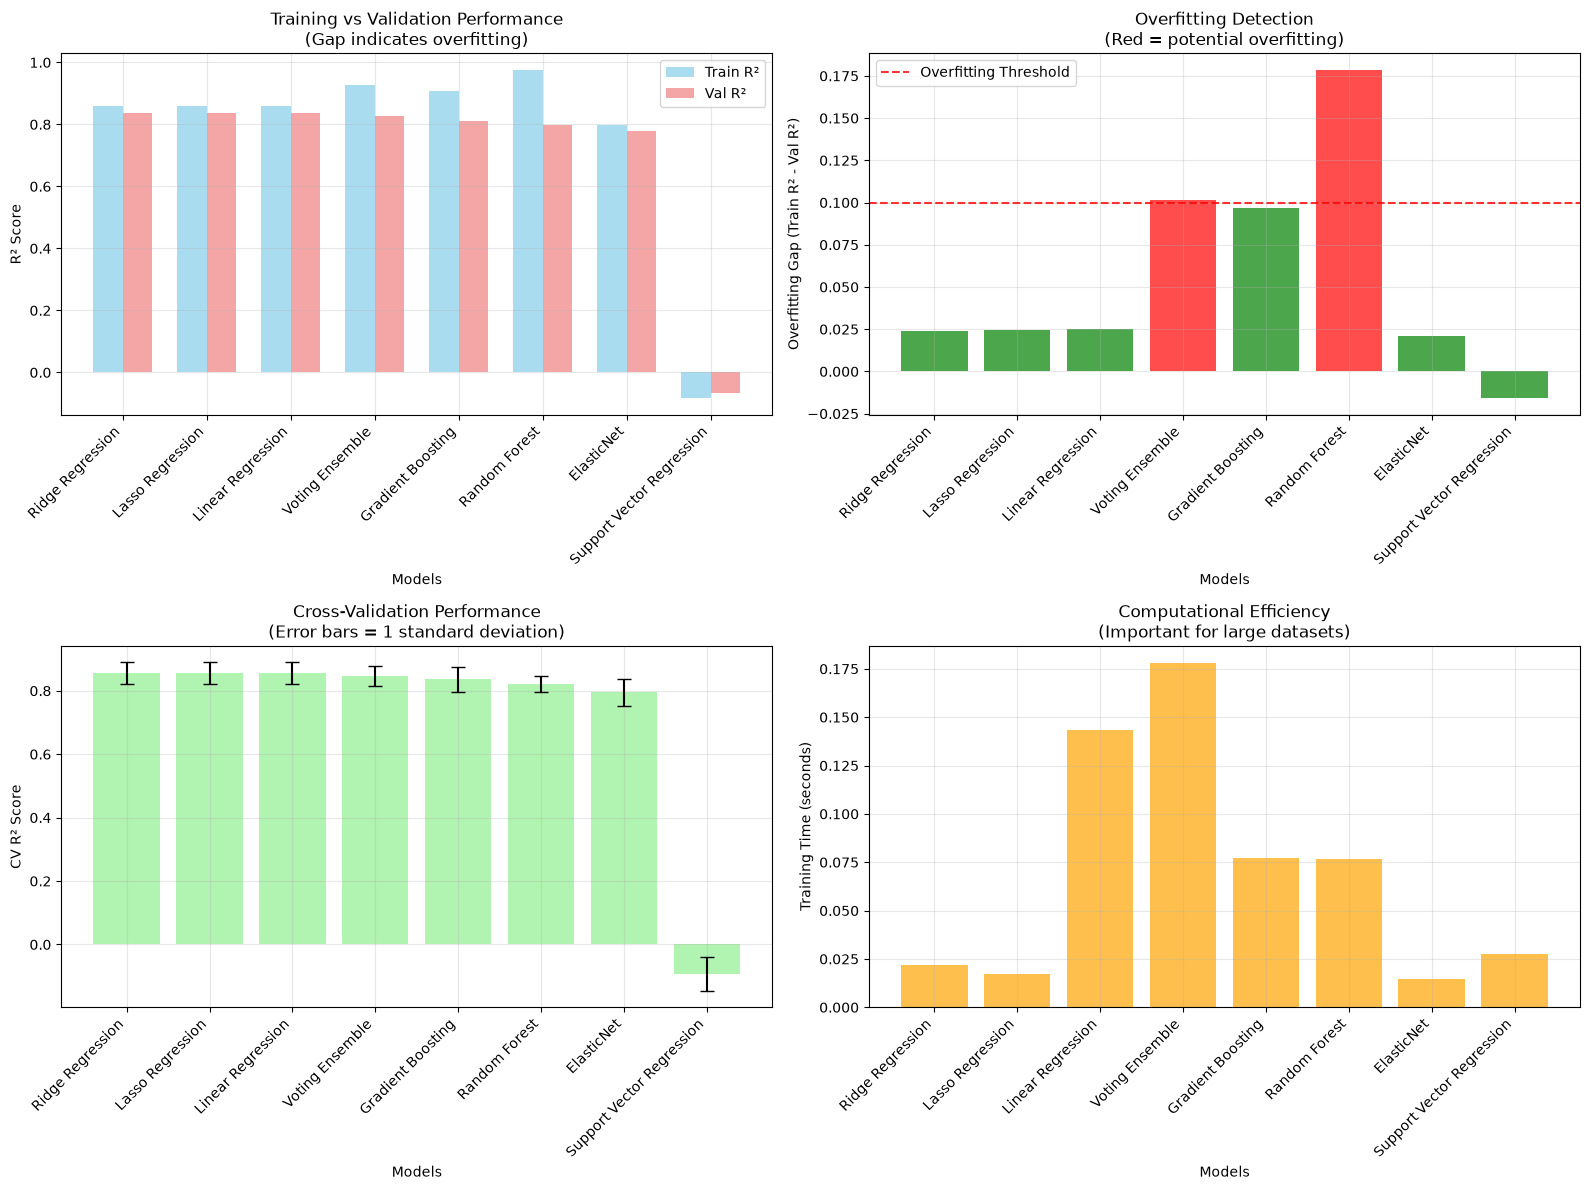


🎯 BEST MODEL SELECTED: Ridge Regression
📊 Validation R²: 0.8364
🔍 CV R²: 0.8552 ± 0.0346

💡 INTERPRETATION GUIDE:
• Good: High R², small train-val gap, stable CV, reasonable training time
• Overfitting: Large gap between train and validation performance
• Unstable: Large CV standard deviation
• Best choice: Balances performance, stability, and efficiency


In [50]:
# 📈 CELL 7: Advanced Model Comparison Visualization
print("📈 ADVANCED MODEL COMPARISON")

# Create comprehensive results dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('val_r2', ascending=False)

print("\n" + "=" * 80)
print("🏆 MODEL PERFORMANCE RANKING")
print("=" * 80)
print(f"{'Model':<25} {'Val R²':<8} {'CV R²':<12} {'Overfitting':<12} {'Time (s)':<10}")
print("-" * 80)

for model_name in results_df.index:
    row = results_df.loc[model_name]
    overfitting_indicator = "⚠️" if row['overfitting_gap'] > 0.1 else "✅"
    print(f"{model_name:<25} {row['val_r2']:>7.4f} {row['cv_r2_mean']:>7.4f} ± {row['cv_r2_std']:>5.4f} "
          f"{overfitting_indicator:>3} {row['overfitting_gap']:>7.4f} {row['training_time']:>9.2f}")

# Comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. R² Comparison
models_ordered = results_df.index
val_r2 = [results[model]['val_r2'] for model in models_ordered]
train_r2 = [results[model]['train_r2'] for model in models_ordered]

x = np.arange(len(models_ordered))
width = 0.35

axes[0, 0].bar(x - width/2, train_r2, width, label='Train R²', alpha=0.7, color='skyblue')
axes[0, 0].bar(x + width/2, val_r2, width, label='Val R²', alpha=0.7, color='lightcoral')
axes[0, 0].set_xlabel('Models')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('Training vs Validation Performance\n(Gap indicates overfitting)')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Overfitting Analysis
overfitting_gaps = [results[model]['overfitting_gap'] for model in models_ordered]
colors = ['red' if gap > 0.1 else 'green' for gap in overfitting_gaps]
axes[0, 1].bar(models_ordered, overfitting_gaps, color=colors, alpha=0.7)
axes[0, 1].axhline(y=0.1, color='red', linestyle='--', alpha=0.8, label='Overfitting Threshold')
axes[0, 1].set_xlabel('Models')
axes[0, 1].set_ylabel('Overfitting Gap (Train R² - Val R²)')
axes[0, 1].set_title('Overfitting Detection\n(Red = potential overfitting)')
axes[0, 1].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Cross-Validation Stability
cv_means = [results[model]['cv_r2_mean'] for model in models_ordered]
cv_stds = [results[model]['cv_r2_std'] for model in models_ordered]
axes[1, 0].bar(models_ordered, cv_means, yerr=cv_stds, capsize=5, alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Models')
axes[1, 0].set_ylabel('CV R² Score')
axes[1, 0].set_title('Cross-Validation Performance\n(Error bars = 1 standard deviation)')
axes[1, 0].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[1, 0].grid(True, alpha=0.3)

# 4. Computational Efficiency
training_times = [results[model]['training_time'] for model in models_ordered]
axes[1, 1].bar(models_ordered, training_times, alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Models')
axes[1, 1].set_ylabel('Training Time (seconds)')
axes[1, 1].set_title('Computational Efficiency\n(Important for large datasets)')
axes[1, 1].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Select best model
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
print(f"\n🎯 BEST MODEL SELECTED: {best_model_name}")
print(f"📊 Validation R²: {results_df.iloc[0]['val_r2']:.4f}")
print(f"🔍 CV R²: {results_df.iloc[0]['cv_r2_mean']:.4f} ± {results_df.iloc[0]['cv_r2_std']:.4f}")

print("\n💡 INTERPRETATION GUIDE:")
print("• Good: High R², small train-val gap, stable CV, reasonable training time")
print("• Overfitting: Large gap between train and validation performance") 
print("• Unstable: Large CV standard deviation")
print("• Best choice: Balances performance, stability, and efficiency")

## Hyperparameter Optimization
I will try to tunn the models have hyperparameters like:
perparameters for several models:
- Random Forest
- Gradient Boosting
- Ridge Regression
- Voting Ensemble

> 🎯 Goal: the best output without overfiting

In [51]:
# Define comprehensive hyperparameter grids
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200, 300],  # Number of trees
        'max_depth': [None, 10, 20, 30],       # Tree depth
        'min_samples_split': [2, 5, 10],       # Minimum samples to split
        'min_samples_leaf': [1, 2, 4],         # Minimum samples per leaf
        'max_features': ['auto', 'sqrt', 'log2']  # Features to consider for splits
    },
    
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],        # Number of boosting stages
        'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Step size shrinkage
        'max_depth': [3, 4, 5, 6],             # Maximum depth per tree
        'min_samples_split': [2, 5, 10],       # Minimum samples to split
        'subsample': [0.8, 0.9, 1.0]           # Fraction of samples for fitting
    },
    
    'Ridge Regression': {
        'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],  # Regularization strength
        'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']  # Algorithm
    },
    
    'Voting Ensemble': {
        'ridge__alpha': [0.1, 1.0, 10.0],
        'rf__n_estimators': [50, 100],
        'rf__max_depth': [10, 20],
        'gb__n_estimators': [50, 100],
        'gb__learning_rate': [0.05, 0.1]
    }
} 

## 📝 Steps: Hyperparameter Optimization

1. **Initialize storage**  
   - `tuned_models` will store the best model for each algorithm.  
   - `optimization_results` will store the best score and parameters for each model.

2. **Loop over each model**  
   - Models: Random Forest, Gradient Boosting, Ridge Regression, Voting Ensemble.  

3. **Start MLflow tracking**  
   - Each model tuning run is logged with `mlflow.start_run(run_name=model_name_tuned)`.

4. **Run RandomizedSearchCV**  
   - Tries `n_iter=20` random combinations from the model’s hyperparameter grid.  
   - Uses cross-validation (`cv=config.CV_FOLDS`) to estimate performance.  
   - Scores models using R² (`scoring='r2'`).

5. **Fit the search**  
   - Fits the model on the training data and finds the best hyperparameters.

6. **Store best results**  
   - Best model saved in `tuned_models`.  
   - Best score and parameters saved in `optimization_results`.

7. **Log everything to MLflow**  
   - Hyperparameters, best cross-validation score, and the tuned model artifact.

8. **Print summary**  
   - Shows best CV R² and the parameters found for each model.

> 🎯 Goal: Automatically find the best hyperparameter settings to maximize model performance while keeping tracking and reproducibility simple.

In [52]:
# "auto" is not supported by your installed scikit-learn version.
param_grids["Random Forest"]["max_features"] = [1.0, "sqrt", "log2"]

print("Starting hyperparameter optimization...")

tuned_models = {}
optimization_results = {}

models_to_tune = [
    "Random Forest",
    "Gradient Boosting",
    "Ridge Regression",
    "Voting Ensemble",
]

for model_name in models_to_tune:
    print(f"\nTuning {model_name}...")

    # Include preprocessing so categorical columns are encoded
    # separately within each cross-validation fold.
    model_pipeline = build_model_pipeline(advanced_models[model_name])

    # The estimator is the "regressor" step in the pipeline.
    # Nested VotingRegressor keys are prefixed the same way.
    param_distributions = {
        f"regressor__{parameter}": values
        for parameter, values in param_grids[model_name].items()
    }

    search = RandomizedSearchCV(
        estimator=model_pipeline,
        param_distributions=param_distributions,
        n_iter=20,
        cv=config.CV_FOLDS,
        scoring="r2",
        n_jobs=config.N_JOBS,
        random_state=config.RANDOM_STATE,
        verbose=1,
        error_score="raise",
    )

    with mlflow.start_run(run_name=f"{model_name}_tuned"):
        search.fit(X_train, y_train)

        best_pipeline = search.best_estimator_
        tuned_models[model_name] = best_pipeline
        optimization_results[model_name] = {
            "best_score": search.best_score_,
            "best_params": search.best_params_,
            "best_estimator": best_pipeline,
        }

        mlflow.log_params(
            {key: str(value) for key, value in search.best_params_.items()}
        )
        mlflow.log_metric("best_cv_r2", float(search.best_score_))

        mlflow.sklearn.log_model(
            best_pipeline,
            name="tuned_model",
            serialization_format="cloudpickle",
        )

    print(f"Best CV R²: {search.best_score_:.4f}")
    print(f"Best parameters: {search.best_params_}")

print(f"\n🎉 HYPERPARAMETER OPTIMIZATION COMPLETE!")
print(f"💡 All tuned models saved in MLflow for comparison")

Starting hyperparameter optimization...

Tuning Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/10/07 20:23:25 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing
2026/10/07 20:23:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/07 20:23:25 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing
2026/10/07 20:23:25 INFO mlflow.utils.environment: Detected uv project at /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing. Attempting to export requirements via 'uv export'.
2026/10/07 20:23:25 INFO mlflow.utils.uv_utils: Exported 106 dependencies via uv

Best CV R²: 0.8474
Best parameters: {'regressor__n_estimators': 200, 'regressor__min_samples_split': 10, 'regressor__min_samples_leaf': 4, 'regressor__max_features': 'sqrt', 'regressor__max_depth': None}

Tuning Gradient Boosting...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/10/07 20:23:27 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing
2026/10/07 20:23:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/07 20:23:27 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing
2026/10/07 20:23:27 INFO mlflow.utils.environment: Detected uv project at /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing. Attempting to export requirements via 'uv export'.
2026/10/07 20:23:27 INFO mlflow.utils.uv_utils: Exported 106 dependencies via uv

Best CV R²: 0.8398
Best parameters: {'regressor__subsample': 0.8, 'regressor__n_estimators': 50, 'regressor__min_samples_split': 10, 'regressor__max_depth': 4, 'regressor__learning_rate': 0.05}

Tuning Ridge Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/10/07 20:23:28 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing
2026/10/07 20:23:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/07 20:23:28 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing
2026/10/07 20:23:28 INFO mlflow.utils.environment: Detected uv project at /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing. Attempting to export requirements via 'uv export'.
2026/10/07 20:23:28 INFO mlflow.utils.uv_utils: Exported 106 dependencies via uv

Best CV R²: 0.8552
Best parameters: {'regressor__solver': 'lsqr', 'regressor__alpha': 0.1}

Tuning Voting Ensemble...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/10/07 20:23:32 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing
2026/10/07 20:23:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/07 20:23:32 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing
2026/10/07 20:23:32 INFO mlflow.utils.environment: Detected uv project at /Users/Haru/Documents/Data_Science/ML_Project/learn_by_doing. Attempting to export requirements via 'uv export'.
2026/10/07 20:23:32 INFO mlflow.utils.uv_utils: Exported 106 dependencies via uv

Best CV R²: 0.8492
Best parameters: {'regressor__ridge__alpha': 0.1, 'regressor__rf__n_estimators': 100, 'regressor__rf__max_depth': 10, 'regressor__gb__n_estimators': 100, 'regressor__gb__learning_rate': 0.05}

🎉 HYPERPARAMETER OPTIMIZATION COMPLETE!
💡 All tuned models saved in MLflow for comparison


Model                Untuned R²   Tuned R²     Improvement 
------------------------------------------------------------
Random Forest            0.7975     0.8306 📈   0.0330
Gradient Boosting        0.8124     0.8189 📈   0.0065
Ridge Regression         0.8364     0.8356 📉  -0.0008
Voting Ensemble          0.8259     0.8292 📈   0.0033


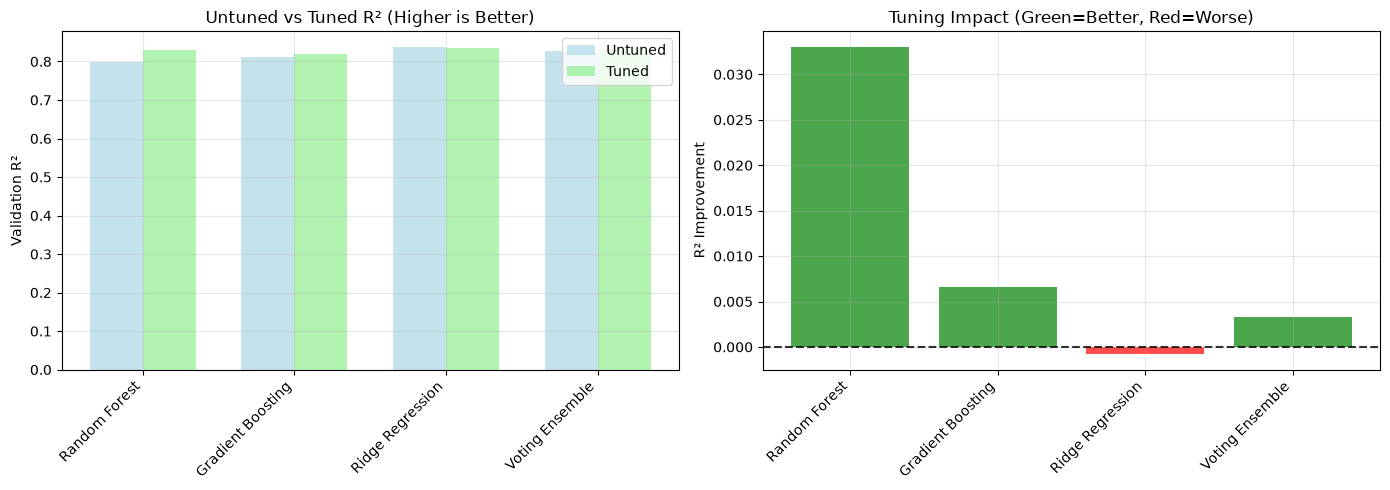


🏆 BEST TUNED MODEL: Ridge Regression
📊 Validation R²: 0.8356
📈 Improvement over untuned: +-0.0008


In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# ===========================
# 1️⃣ Evaluate tuned models on validation set
# ===========================
tuned_results = {}
for model_name, tuned_model in tuned_models.items():
    y_val_pred = tuned_model.predict(X_val)
    val_r2 = r2_score(y_val, y_val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    improvement = val_r2 - results[model_name]['val_r2']  # vs untuned
    
    tuned_results[model_name] = {
        'val_r2': val_r2,
        'val_rmse': val_rmse,
        'improvement': improvement
    }

# ===========================
# 2️⃣ Print simple comparison table
# ===========================
print(f"{'Model':<20} {'Untuned R²':<12} {'Tuned R²':<12} {'Improvement':<12}")
print("-" * 60)
for model_name, res in tuned_results.items():
    untuned_r2 = results[model_name]['val_r2']
    tuned_r2 = res['val_r2']
    improvement = res['improvement']
    icon = "📈" if improvement > 0 else "📉" if improvement < 0 else "➡️"
    print(f"{model_name:<20} {untuned_r2:>10.4f} {tuned_r2:>10.4f} {icon} {improvement:>8.4f}")

# ===========================
# 3️⃣ Plot Tuned vs Untuned R²
# ===========================
models = list(tuned_results.keys())
untuned_r2 = [results[m]['val_r2'] for m in models]
tuned_r2 = [tuned_results[m]['val_r2'] for m in models]
improvement = [tuned_results[m]['improvement'] for m in models]

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# R² comparison
axes[0].bar(x - width/2, untuned_r2, width, label='Untuned', alpha=0.7, color='lightblue')
axes[0].bar(x + width/2, tuned_r2, width, label='Tuned', alpha=0.7, color='lightgreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylabel('Validation R²')
axes[0].set_title('Untuned vs Tuned R² (Higher is Better)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Improvement plot
colors = ['green' if i>0 else 'red' for i in improvement]
axes[1].bar(models, improvement, color=colors, alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.8)
axes[1].set_ylabel('R² Improvement')
axes[1].set_title('Tuning Impact (Green=Better, Red=Worse)')
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ===========================
# 4️⃣ Best tuned model
# ===========================
best_model_name = max(tuned_results, key=lambda m: tuned_results[m]['val_r2'])
print(f"\n🏆 BEST TUNED MODEL: {best_model_name}")
print(f"📊 Validation R²: {tuned_results[best_model_name]['val_r2']:.4f}")
print(f"📈 Improvement over untuned: +{tuned_results[best_model_name]['improvement']:.4f}")


# 🚀 Model Deployment Preparation
Now that we have selected the best tuned model and confirmed it generalizes well on the validation (and test) data, we can prepare it for deployment.

# This involves several important steps:
1️⃣ Identify the best model based on validation performance.

2️⃣ Version the model and save both the trained model and preprocessing pipeline.

3️⃣ Create a comprehensive model card containing metadata, performance metrics, data information, model configuration, preprocessing steps, and deployment instructions.

4️⃣ Save deployment requirements to ensure reproducibility in production.

These steps ensure that the model is production-ready and can be deployed (e.g., via Streamlit) in a consistent, versioned, and well-documented manner.


In [56]:
from datetime import datetime, timezone
from pathlib import Path
import json
import cloudpickle


best_model_name = max(
    tuned_results,
    key=lambda name: tuned_results[name]["val_r2"],
)
final_pipeline = tuned_models[best_model_name]

model_dir = Path(config.MODEL_DIR)
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "insurance_cost_pipeline.pkl"
model_card_path = model_dir / "insurance_model_card.json"

with model_path.open("wb") as file:
    cloudpickle.dump(final_pipeline, file)

model_card = {
    "model_name": best_model_name,
    "model_version": datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ"),
    "target": "charges",
    "features": list(X_train.columns),
    "selection_metric": "validation R²",
    "validation_metrics": {
        "r2": float(tuned_results[best_model_name]["val_r2"]),
        "rmse": float(tuned_results[best_model_name]["val_rmse"]),
    },
    "best_cross_validation_r2": float(
        optimization_results[best_model_name]["best_score"]
    ),
    "test_metrics": {
        "r2": float(test_r2),
        "rmse": float(test_rmse),
        "mae": float(test_mae),
    },
    "best_parameters": {
        name: str(value)
        for name, value in optimization_results[best_model_name][
            "best_params"
        ].items()
    },
    "data_split_rows": {
        "train": int(len(X_train)),
        "validation": int(len(X_val)),
        "test": int(len(X_test)),
    },
}

model_card_path.write_text(json.dumps(model_card, indent=2))

print(f"Selected model: {best_model_name}")
print(f"Pipeline saved to: {model_path}")
print(f"Model card saved to: {model_card_path}")

Selected model: Ridge Regression
Pipeline saved to: models/insurance_cost_pipeline.pkl
Model card saved to: models/insurance_model_card.json
